# Backpropagation From Scratch

In [1]:
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1. DATA


# Simple binary classification dataset
# OR logic
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
], dtype=float)

y = np.array([
    [0],
    [1],
    [1],
    [1]
], dtype=float)


# ============================================================
# 2. ACTIVATION FUNCTION
# ============================================================

def sigmoid(x):
    return 1 / (1 + np.exp(-x))


# Derivative of sigmoid
def sigmoid_derivative(x):
    return x * (1 - x)


# ============================================================
# 3. INITIALIZE WEIGHTS AND BIASES
# ============================================================

np.random.seed(42)

# Input layer = 2 neurons
# Hidden layer = 2 neurons
# Output layer = 1 neuron

W1 = np.random.randn(2, 2)
b1 = np.zeros((1, 2))

W2 = np.random.randn(2, 1)
b2 = np.zeros((1, 1))


# ============================================================
# 4. TRAINING SETTINGS
# ============================================================

learning_rate = 0.5
epochs = 10000

loss_history = []


# ============================================================
# 5. TRAINING
# ============================================================

for epoch in range(epochs):

    # --------------------------------------------------------
    # FORWARD PROPAGATION
    # --------------------------------------------------------

    # Input → Hidden Layer
    z1 = np.dot(X, W1) + b1
    a1 = sigmoid(z1)

    # Hidden Layer → Output Layer
    z2 = np.dot(a1, W2) + b2
    a2 = sigmoid(z2)

    # Prediction
    y_pred = a2


    # --------------------------------------------------------
    # LOSS
    # --------------------------------------------------------

    epsilon = 1e-8

    loss = -np.mean(
        y * np.log(y_pred + epsilon)
        +
        (1 - y) * np.log(1 - y_pred + epsilon)
    )

    loss_history.append(loss)


    # --------------------------------------------------------
    # BACKPROPAGATION
    # --------------------------------------------------------

    # Number of samples
    m = len(X)

    # Output layer error
    dz2 = y_pred - y

    # Gradient of W2
    dW2 = np.dot(a1.T, dz2) / m

    # Gradient of b2
    db2 = np.sum(dz2, axis=0, keepdims=True) / m


    # Hidden layer error
    dz1 = np.dot(dz2, W2.T) * sigmoid_derivative(a1)

    # Gradient of W1
    dW1 = np.dot(X.T, dz1) / m

    # Gradient of b1
    db1 = np.sum(dz1, axis=0, keepdims=True) / m


    # --------------------------------------------------------
    # UPDATE WEIGHTS AND BIASES
    # --------------------------------------------------------

    W2 = W2 - learning_rate * dW2
    b2 = b2 - learning_rate * db2

    W1 = W1 - learning_rate * dW1
    b1 = b1 - learning_rate * db1


# ============================================================
# 6. FINAL PREDICTIONS
# ============================================================

print("Final Predictions:")

print(y_pred)

print("\nRounded Predictions:")

print(np.round(y_pred))


# ============================================================
# 7. ACCURACY
# ============================================================

predicted_classes = (y_pred >= 0.5).astype(int)

accuracy = np.mean(predicted_classes == y)

print("\nActual Values:")
print(y.flatten())

print("\nPredicted Classes:")
print(predicted_classes.flatten())

print("\nAccuracy:", accuracy * 100, "%")








Final Predictions:
[[0.00176915]
 [0.99955527]
 [0.99955465]
 [0.99990827]]

Rounded Predictions:
[[0.]
 [1.]
 [1.]
 [1.]]

Actual Values:
[0. 1. 1. 1.]

Predicted Classes:
[0 1 1 1]

Accuracy: 100.0 %


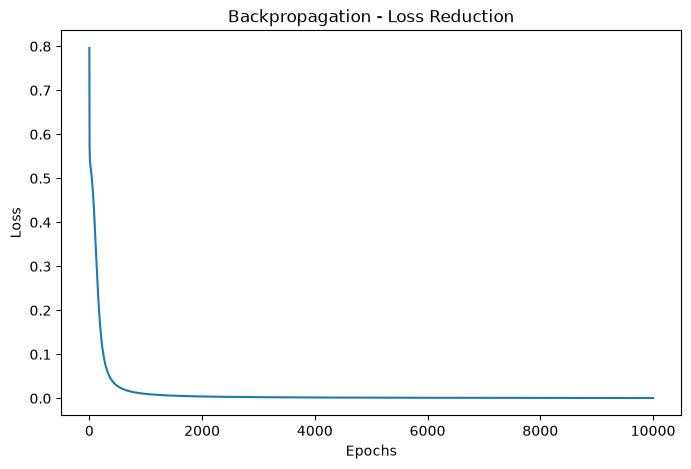

In [2]:
# 8. LOSS GRAPH
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(loss_history)

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Backpropagation - Loss Reduction")

plt.show()



In [3]:
# 9. TEST THE NETWORK

test_data = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
], dtype=float)

# Forward propagation for test data

test_z1 = np.dot(test_data, W1) + b1
test_a1 = sigmoid(test_z1)

test_z2 = np.dot(test_a1, W2) + b2
test_predictions = sigmoid(test_z2)

print("\nTest Predictions:")

for i in range(len(test_data)):
    print(
        test_data[i],
        "→",
        round(float(test_predictions[i][0]), 4),
        "→",
        int(test_predictions[i][0] >= 0.5)
    )


Test Predictions:
[0. 0.] → 0.0018 → 0
[0. 1.] → 0.9996 → 1
[1. 0.] → 0.9996 → 1
[1. 1.] → 0.9999 → 1
